In [9]:
import datetime
import math
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import zipfile
import requests

from utilities.loaders import charge_raw_data, download_dataset

from utilities.preprocessors import (which_element,
    find_begin_end,
    interpolate_signals,
    butter_lowpass_filter,
    concur_extract_features_from_all,
    extract_features_per_hour,
    get_time_frequency,
    rejoin_data,
    load_wavelet_data, 
    restructure_wavelets, 
    compute_features)

from utilities.visualizers import (view_time_frame,
    view_wavelet_coeffs,
    analyze,
    data_split_metric_values,
    view_value_frequency,
    multi_class_heatmap,
    view_metric_values,
    view_classified_labels,
    view_label_freq,
    disp_cat_feat,
    plot_all_features,
    describe_col,
    ModelResults,
    view_all_splits_results)

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Downloading dataset

If your project requires downloading a larger file, then you may run into issues using the steps above when you try to load the entire file into memory. To overcome those issues, you can download large files in a streaming fashion to avoid reading the content of large responses all at once

In [10]:
# download_dataset("https://prod-dcd-datasets-cache-zipfiles.s3.eu-west-1.amazonaws.com/w8fxrg4pv5-2.zip")

# Loading dataset

In [11]:
# # Extract data from zip file
# with zipfile.ZipFile('./data/Electrodermal Activity artifact correction BEnchmark (EDABE)/EDABE dataset.zip', 'r') as zip_ref:
#     zip_ref.extractall('./data/Electrodermal Activity artifact correction BEnchmark (EDABE)')

In [12]:
ahixac_eda_df_128hz = pd.read_csv('./data/Electrodermal Activity artifact correction BEnchmark (EDABE)/Train/ahixac_expert1.csv', sep=';')
ahixac_eda_df_128hz

,time,rawdata,cleandata,binarytarget,signal_automatic,PredArtifacts,PostProcessedPredArtifacts
0,0.000000,0.000000,-0.164015,0.0,2.106994e-20,1.0,1.0
1,0.007812,0.000000,-0.127567,0.0,1.879714e-06,1.0,1.0
2,0.015625,0.000000,-0.127567,0.0,3.656027e-06,1.0,1.0
3,0.023438,0.000000,-0.127567,0.0,5.370973e-06,1.0,1.0
4,0.031250,0.000000,-0.127567,0.0,7.062509e-06,1.0,1.0
...,...,...,...,...,...,...,...
832825,6506.445312,2.591209,2.591209,0.0,2.591209e+00,0.0,0.0
832826,6506.453125,2.585348,2.585348,0.0,2.585348e+00,0.0,0.0
832827,6506.460938,2.602930,2.602930,0.0,2.602930e+00,0.0,0.0
832828,6506.468750,2.570696,2.570696,0.0,2.570696e+00,0.0,0.0


In [13]:
ahixac_eda_df_128hz.columns = ['time', 'raw_signal', 'clean_signal', 'label', 'auto_signal', 'pred_art', 'post_proc_pred_art']

In [14]:
start_time = ahixac_eda_df_128hz.iloc[0]['time']
start_time

0.0

In [15]:
ahixac_eda_df_128hz.set_index(pd.date_range(start=start_time, periods=ahixac_eda_df_128hz.shape[0], freq=get_time_frequency(128)), inplace=True)
ahixac_eda_df_128hz

,time,raw_signal,clean_signal,label,auto_signal,pred_art,post_proc_pred_art
1970-01-01 00:00:00.000000000,0.000000,0.000000,-0.164015,0.0,2.106994e-20,1.0,1.0
1970-01-01 00:00:00.007812500,0.007812,0.000000,-0.127567,0.0,1.879714e-06,1.0,1.0
1970-01-01 00:00:00.015625000,0.015625,0.000000,-0.127567,0.0,3.656027e-06,1.0,1.0
1970-01-01 00:00:00.023437500,0.023438,0.000000,-0.127567,0.0,5.370973e-06,1.0,1.0
1970-01-01 00:00:00.031250000,0.031250,0.000000,-0.127567,0.0,7.062509e-06,1.0,1.0
...,...,...,...,...,...,...,...
1970-01-01 01:48:26.445312500,6506.445312,2.591209,2.591209,0.0,2.591209e+00,0.0,0.0
1970-01-01 01:48:26.453125000,6506.453125,2.585348,2.585348,0.0,2.585348e+00,0.0,0.0
1970-01-01 01:48:26.460937500,6506.460938,2.602930,2.602930,0.0,2.602930e+00,0.0,0.0
1970-01-01 01:48:26.468750000,6506.468750,2.570696,2.570696,0.0,2.570696e+00,0.0,0.0


# Downsampling 128hz signals to 16hz

In [16]:
ahixac_eda_df_16hz = interpolate_signals(ahixac_eda_df_128hz, sample_rate=128, start_time=start_time, target_hz=16)
ahixac_eda_df_16hz

,time,raw_signal,clean_signal,label,auto_signal,pred_art,post_proc_pred_art
1970-01-01 00:00:00.000000,0.0000,0.000000,-0.164015,0.0,2.106994e-20,1.0,1.0
1970-01-01 00:00:00.062500,0.0625,0.000000,-0.022974,0.0,1.357508e-05,1.0,1.0
1970-01-01 00:00:00.125000,0.1250,0.000000,-0.022974,0.0,2.747785e-05,1.0,1.0
1970-01-01 00:00:00.187500,0.1875,0.000000,-0.005128,0.0,5.611462e-05,1.0,1.0
1970-01-01 00:00:00.250000,0.2500,0.000222,0.000222,0.0,1.260593e-04,1.0,1.0
...,...,...,...,...,...,...,...
1970-01-01 01:48:26.187500,6506.1875,2.547253,2.547253,0.0,2.547253e+00,0.0,0.0
1970-01-01 01:48:26.250000,6506.2500,2.554579,2.554579,0.0,2.554579e+00,0.0,0.0
1970-01-01 01:48:26.312500,6506.3125,2.594139,2.594139,0.0,2.594139e+00,0.0,0.0
1970-01-01 01:48:26.375000,6506.3750,2.592674,2.592674,0.0,2.592674e+00,0.0,0.0


# Low-pass filtering raw 128hz and 16hz signals 

In [17]:
ahixac_eda_df_128hz['filtered_signal'] = butter_lowpass_filter(ahixac_eda_df_128hz['raw_signal'], cutoff=1.0, samp_freq=128, order=6)
ahixac_eda_df_16hz['filtered_signal'] = butter_lowpass_filter(ahixac_eda_df_16hz['raw_signal'], cutoff=1.0, samp_freq=16, order=6)

C:\Users\Mig\AppData\Local\Temp\ipykernel_15108\3441688614.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ahixac_eda_df_16hz['filtered_signal'] = butter_lowpass_filter(ahixac_eda_df_16hz['raw_signal'], cutoff=1.0, samp_freq=16, order=6)


In [18]:
ahixac_eda_df_128hz

,time,raw_signal,clean_signal,label,auto_signal,pred_art,post_proc_pred_art,filtered_signal
1970-01-01 00:00:00.000000000,0.000000,0.000000,-0.164015,0.0,2.106994e-20,1.0,1.0,0.000000
1970-01-01 00:00:00.007812500,0.007812,0.000000,-0.127567,0.0,1.879714e-06,1.0,1.0,0.000000
1970-01-01 00:00:00.015625000,0.015625,0.000000,-0.127567,0.0,3.656027e-06,1.0,1.0,0.000000
1970-01-01 00:00:00.023437500,0.023438,0.000000,-0.127567,0.0,5.370973e-06,1.0,1.0,0.000000
1970-01-01 00:00:00.031250000,0.031250,0.000000,-0.127567,0.0,7.062509e-06,1.0,1.0,0.000000
...,...,...,...,...,...,...,...,...
1970-01-01 01:48:26.445312500,6506.445312,2.591209,2.591209,0.0,2.591209e+00,0.0,0.0,2.610662
1970-01-01 01:48:26.453125000,6506.453125,2.585348,2.585348,0.0,2.585348e+00,0.0,0.0,2.609485
1970-01-01 01:48:26.460937500,6506.460938,2.602930,2.602930,0.0,2.602930e+00,0.0,0.0,2.608305
1970-01-01 01:48:26.468750000,6506.468750,2.570696,2.570696,0.0,2.570696e+00,0.0,0.0,2.607123


In [19]:
ahixac_eda_df_128hz.iloc[63]

time                  0.492188
raw_signal            0.000222
clean_signal          0.000222
label                 0.000000
auto_signal           0.000219
pred_art              1.000000
post_proc_pred_art    1.000000
filtered_signal       0.000002
Name: 1970-01-01 00:00:00.492187500, dtype: float64

In [20]:
timestamp_list = ahixac_eda_df_128hz.index.tolist()[::64]
timestamp_list

[Timestamp('1970-01-01 00:00:00'),
 Timestamp('1970-01-01 00:00:00.500000'),
 Timestamp('1970-01-01 00:00:01'),
 Timestamp('1970-01-01 00:00:01.500000'),
 Timestamp('1970-01-01 00:00:02'),
 Timestamp('1970-01-01 00:00:02.500000'),
 Timestamp('1970-01-01 00:00:03'),
 Timestamp('1970-01-01 00:00:03.500000'),
 Timestamp('1970-01-01 00:00:04'),
 Timestamp('1970-01-01 00:00:04.500000'),
 Timestamp('1970-01-01 00:00:05'),
 Timestamp('1970-01-01 00:00:05.500000'),
 Timestamp('1970-01-01 00:00:06'),
 Timestamp('1970-01-01 00:00:06.500000'),
 Timestamp('1970-01-01 00:00:07'),
 Timestamp('1970-01-01 00:00:07.500000'),
 Timestamp('1970-01-01 00:00:08'),
 Timestamp('1970-01-01 00:00:08.500000'),
 Timestamp('1970-01-01 00:00:09'),
 Timestamp('1970-01-01 00:00:09.500000'),
 Timestamp('1970-01-01 00:00:10'),
 Timestamp('1970-01-01 00:00:10.500000'),
 Timestamp('1970-01-01 00:00:11'),
 Timestamp('1970-01-01 00:00:11.500000'),
 Timestamp('1970-01-01 00:00:12'),
 Timestamp('1970-01-01 00:00:12.500000'),

In [21]:
timestamp_list[-1].timestamp()

6506.0

In [22]:
ahixac_eda_df_16hz

,time,raw_signal,clean_signal,label,auto_signal,pred_art,post_proc_pred_art,filtered_signal
1970-01-01 00:00:00.000000,0.0000,0.000000,-0.164015,0.0,2.106994e-20,1.0,1.0,0.000000e+00
1970-01-01 00:00:00.062500,0.0625,0.000000,-0.022974,0.0,1.357508e-05,1.0,1.0,0.000000e+00
1970-01-01 00:00:00.125000,0.1250,0.000000,-0.022974,0.0,2.747785e-05,1.0,1.0,0.000000e+00
1970-01-01 00:00:00.187500,0.1875,0.000000,-0.005128,0.0,5.611462e-05,1.0,1.0,0.000000e+00
1970-01-01 00:00:00.250000,0.2500,0.000222,0.000222,0.0,1.260593e-04,1.0,1.0,6.399354e-09
...,...,...,...,...,...,...,...,...
1970-01-01 01:48:26.187500,6506.1875,2.547253,2.547253,0.0,2.547253e+00,0.0,0.0,2.627107e+00
1970-01-01 01:48:26.250000,6506.2500,2.554579,2.554579,0.0,2.554579e+00,0.0,0.0,2.621452e+00
1970-01-01 01:48:26.312500,6506.3125,2.594139,2.594139,0.0,2.594139e+00,0.0,0.0,2.614561e+00
1970-01-01 01:48:26.375000,6506.3750,2.592674,2.592674,0.0,2.592674e+00,0.0,0.0,2.606552e+00


In [23]:
ahixac_eda_df_16hz[:8]

,time,raw_signal,clean_signal,label,auto_signal,pred_art,post_proc_pred_art,filtered_signal
1970-01-01 00:00:00.000000,0.0000,0.000000,-0.164015,0.0,2.106994e-20,1.0,1.0,0.000000e+00
1970-01-01 00:00:00.062500,0.0625,0.000000,-0.022974,0.0,1.357508e-05,1.0,1.0,0.000000e+00
1970-01-01 00:00:00.125000,0.1250,0.000000,-0.022974,0.0,2.747785e-05,1.0,1.0,0.000000e+00
1970-01-01 00:00:00.187500,0.1875,0.000000,-0.005128,0.0,5.611462e-05,1.0,1.0,0.000000e+00
1970-01-01 00:00:00.250000,0.2500,0.000222,0.000222,0.0,1.260593e-04,1.0,1.0,6.399354e-09
1970-01-01 00:00:00.312500,0.3125,0.000222,0.000222,0.0,1.814013e-04,1.0,1.0,7.349379e-08
1970-01-01 00:00:00.375000,0.3750,0.000222,0.000222,0.0,1.960738e-04,1.0,1.0,4.157932e-07
1970-01-01 00:00:00.437500,0.4375,0.000222,0.000222,0.0,2.102826e-04,1.0,1.0,1.562775e-06


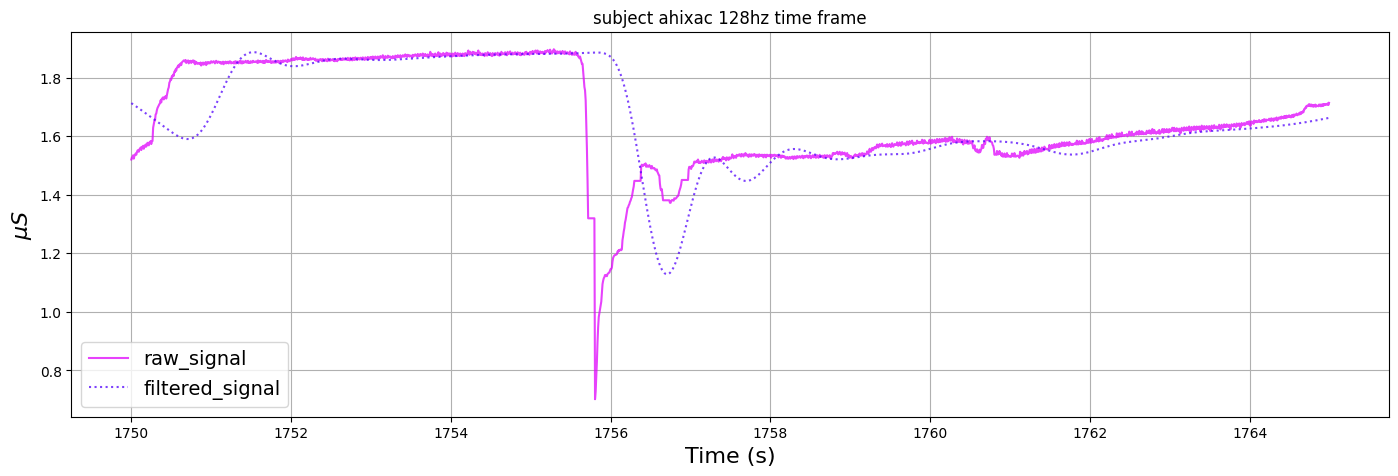

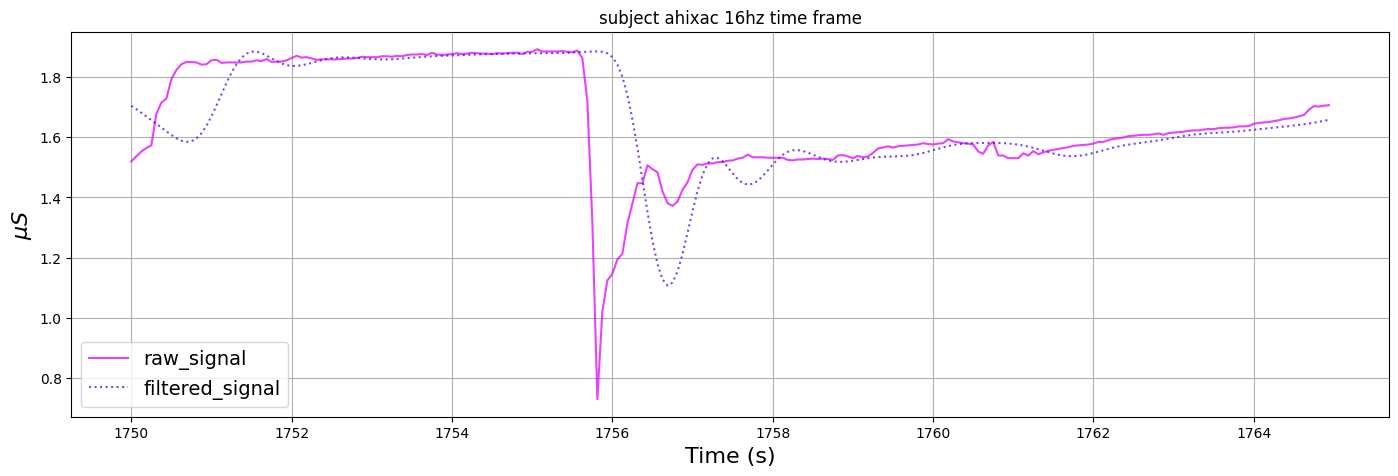

In [24]:
view_time_frame(ahixac_eda_df_128hz, samp_freq=128, cols_to_use=['raw_signal', 'filtered_signal'], img_title='subject ahixac 128hz time frame')
view_time_frame(ahixac_eda_df_16hz, samp_freq=16, cols_to_use=['raw_signal', 'filtered_signal'], img_title='subject ahixac 16hz time frame')

# Iterate through signals per hour

In [25]:
data_128hz = extract_features_per_hour(ahixac_eda_df_128hz, hertz=128, window_size=0.5, verbose=True)
data_128hz

processing hour 0 - start: 0 | end: 460800


d:\Projects\To Github\thesis-writing-1\eda-signal-classifier\utilities\preprocessors.py:192: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  whole_inc_ts = pd.date_range(start=timestamp_list[0], periods=data.shape[0], freq=f'{((1 / whole_freq) * 1000)}ms')
d:\Projects\To Github\thesis-writing-1\eda-signal-classifier\utilities\preprocessors.py:193: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  half_inc_ts = pd.date_range(start=timestamp_list[0], periods=data.shape[0], freq=f'{((1 / half_freq) * 1000)}ms')


processing hour 1 - start: 460800 | end: 832830


d:\Projects\To Github\thesis-writing-1\eda-signal-classifier\utilities\preprocessors.py:192: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  whole_inc_ts = pd.date_range(start=timestamp_list[0], periods=data.shape[0], freq=f'{((1 / whole_freq) * 1000)}ms')
d:\Projects\To Github\thesis-writing-1\eda-signal-classifier\utilities\preprocessors.py:193: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  half_inc_ts = pd.date_range(start=timestamp_list[0], periods=data.shape[0], freq=f'{((1 / half_freq) * 1000)}ms')


[(                         raw_128hz_amp  raw_128hz_1d_max  raw_128hz_1d_min  \
  1970-01-01 00:00:00.000       0.000118          0.000111          0.000000   
  1970-01-01 00:00:00.500       0.000222          0.000111          0.000111   
  1970-01-01 00:00:01.000       0.000222          0.000111          0.000111   
  1970-01-01 00:00:01.500       0.000222          0.000111          0.000111   
  1970-01-01 00:00:02.000       0.000222          0.000111          0.000111   
  ...                                ...               ...               ...   
  1970-01-01 00:59:57.500       1.488645          0.754212          0.738828   
  1970-01-01 00:59:58.000       1.487408          0.753480          0.738095   
  1970-01-01 00:59:58.500       1.487592          0.752747          0.738095   
  1970-01-01 00:59:59.000       1.487592          0.751282          0.738095   
  1970-01-01 00:59:59.500       0.000000          0.000000          0.000000   
  
                           raw_128hz_

In [26]:
data_16hz = extract_features_per_hour(ahixac_eda_df_16hz, hertz=16, window_size=0.5, verbose=True)
data_16hz

processing hour 0 - start: 0 | end: 57600


d:\Projects\To Github\thesis-writing-1\eda-signal-classifier\utilities\preprocessors.py:192: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  whole_inc_ts = pd.date_range(start=timestamp_list[0], periods=data.shape[0], freq=f'{((1 / whole_freq) * 1000)}ms')
d:\Projects\To Github\thesis-writing-1\eda-signal-classifier\utilities\preprocessors.py:193: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  half_inc_ts = pd.date_range(start=timestamp_list[0], periods=data.shape[0], freq=f'{((1 / half_freq) * 1000)}ms')


processing hour 1 - start: 57600 | end: 104104


d:\Projects\To Github\thesis-writing-1\eda-signal-classifier\utilities\preprocessors.py:192: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  whole_inc_ts = pd.date_range(start=timestamp_list[0], periods=data.shape[0], freq=f'{((1 / whole_freq) * 1000)}ms')
d:\Projects\To Github\thesis-writing-1\eda-signal-classifier\utilities\preprocessors.py:193: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  half_inc_ts = pd.date_range(start=timestamp_list[0], periods=data.shape[0], freq=f'{((1 / half_freq) * 1000)}ms')


[(                         raw_16hz_amp  raw_16hz_1d_max  raw_16hz_1d_min  \
  1970-01-01 00:00:00.000      0.000111         0.000111         0.000000   
  1970-01-01 00:00:00.500      0.000222         0.000111         0.000111   
  1970-01-01 00:00:01.000      0.000222         0.000111         0.000111   
  1970-01-01 00:00:01.500      0.000222         0.000111         0.000111   
  1970-01-01 00:00:02.000      0.000222         0.000111         0.000111   
  ...                               ...              ...              ...   
  1970-01-01 00:59:57.500      1.480220         0.740293         0.739560   
  1970-01-01 00:59:58.000      1.478388         0.740293         0.738095   
  1970-01-01 00:59:58.500      1.479121         0.742491         0.738095   
  1970-01-01 00:59:59.000      1.478571         0.739560         0.738828   
  1970-01-01 00:59:59.500      0.000000         0.000000         0.000000   
  
                           raw_16hz_1d_max_abs  raw_16hz_1d_avg_abs  \
  

#### if we had a 128hz dataset with derived timestamps that increase every 0.5s such as this [0.0, 0.5, 1.0, 1.5, ..., 6506.0] then our segments would be:
```
[0.0, 0.5)
[0.5, 1.0)
[1.0, 1.5)
...
[6504.5, 6506.0)
```

#### 832830 / 64 is 13012.96875 or when "`math.ceil()`ed" is 13013

In [27]:
math.ceil(13012.96875), math.floor(13012.96875)

(13013, 13012)

In [28]:
for feature_segments, labels in data_128hz:
    print(labels.value_counts())

0.0    6484
1.0     716
Name: count, dtype: int64
0.0    5605
1.0     208
Name: count, dtype: int64


#### here in the first hour of our data the number of artifacts out of all 7200 0.5s segments is 716 or roughly 9.9% of our data, and the number of non-artifacts out of all 7200 0.5s segments is 6484 or roughly 90% of our data

#### For the second hour of our data the number of artifacts out of all 5813 0.5s segments is 208 or roughly 3.58% of our data, and the number of non-artifacts out of all 5813 0.5s segments is 5605 or roughly 96.42% of our data

In [29]:
for feature_segments, labels in data_16hz:
    print(labels.value_counts())

0.0    6490
1.0     710
Name: count, dtype: int64
0.0    5609
1.0     204
Name: count, dtype: int64


#### Here the reason why we have almost the same number of artifact and non-artifact labels to the 128hz data is because we interpolated our 128hz data to 16hz thus losing some of our labels 

In [30]:
ahixac_eda_data = rejoin_data(data_128hz, data_16hz)
ahixac_eda_data

d:\Projects\To Github\thesis-writing-1\eda-signal-classifier\utilities\preprocessors.py:575: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  eda_labels = pd.concat([eda_labels, features_per_hour_1[i][1]], ignore_index=True)


(       raw_128hz_amp  raw_128hz_1d_max  raw_128hz_1d_min  \
 0           0.000118          0.000111          0.000000   
 1           0.000222          0.000111          0.000111   
 2           0.000222          0.000111          0.000111   
 3           0.000222          0.000111          0.000111   
 4           0.000222          0.000111          0.000111   
 ...              ...               ...               ...   
 13008       2.695696          1.363004          1.336630   
 13009       2.698558          1.366667          1.334432   
 13010       2.664309          1.357143          1.312454   
 13011       2.616277          1.346886          1.285348   
 13012       0.000000          0.000000          0.000000   
 
        raw_128hz_1d_max_abs  raw_128hz_1d_avg_abs  raw_128hz_2d_max  \
 0                  0.000111              0.000059               0.0   
 1                  0.000111              0.000111               0.0   
 2                  0.000111              0.000111

#### concatenating calculated features from 128hz and 16hz data of the first hour

In [31]:
ahixac_eda_data[0].columns

Index(['raw_128hz_amp', 'raw_128hz_1d_max', 'raw_128hz_1d_min',
       'raw_128hz_1d_max_abs', 'raw_128hz_1d_avg_abs', 'raw_128hz_2d_max',
       'raw_128hz_2d_min', 'raw_128hz_2d_max_abs', 'raw_128hz_2d_avg_abs',
       'filt_128hz_amp', 'filt_128hz_1d_max', 'filt_128hz_1d_min',
       'filt_128hz_1d_max_abs', 'filt_128hz_1d_avg_abs', 'filt_128hz_2d_max',
       'filt_128hz_2d_min', 'filt_128hz_2d_max_abs', 'filt_128hz_2d_avg_abs',
       'first_16thofa_sec_max', 'second_16thofa_sec_max',
       'third_16thofa_sec_max', 'first_16thofa_sec_mean',
       'second_16thofa_sec_mean', 'third_16thofa_sec_mean',
       'first_16thofa_sec_std', 'second_16thofa_sec_std',
       'third_16thofa_sec_std', 'first_16thofa_sec_median',
       'second_16thofa_sec_median', 'third_16thofa_sec_median',
       'first_16thofa_sec_n_coeffs_above_zero',
       'second_16thofa_sec_n_coeffs_above_zero',
       'third_16thofa_sec_n_coeffs_above_zero', 'first_32thofa_sec_max',
       'second_32thofa_sec_max', 'f

# Now we ought to do these for all subjects

# scanning train folder

In [32]:
train_files = os.listdir('./data/Electrodermal Activity artifact correction BEnchmark (EDABE)/Train/')
train_files

['ahixac_expert1.csv',
 'akakip_expert2.csv',
 'aqamom_expert2.csv',
 'aretez_expert1.csv',
 'asifex_expert2.csv',
 'axeyoh_expert2.csv',
 'efawep_expert2.csv',
 'egemow_expert2.csv',
 'ejofeq_expert2.csv',
 'erecij_expert1.csv',
 'esirur_expert1.csv',
 'ewehov_expert2.csv',
 'exozef_expert2.csv',
 'idagah_expert2.csv',
 'ihikay_expert1.csv',
 'ihinot_expert1.csv',
 'imocac_expert2.csv',
 'iqiyat_expert2.csv',
 'obujoh_expert2.csv',
 'ohayeh_expert1.csv',
 'ohufow_expert1.csv',
 'ojotew_expert1.csv',
 'onivuk_expert1.csv',
 'opunad_expert1.csv',
 'otecab_expert2.csv',
 'otuqom_expert1.csv',
 'owegud_expert2.csv',
 'oxisux_expert1.csv',
 'tchgij_expert2.csv',
 'ufoyek_expert2.csv',
 'uqozew_expert1.csv',
 'urogif_expert1.csv',
 'uzefow_expert1.csv']

# Concurrently read each .csv file and use functions that will spit out the features

In [33]:
train_eda_data = concur_extract_features_from_all('./data/Electrodermal Activity artifact correction BEnchmark (EDABE)/Train/', train_files)
train_eda_data

d:\Projects\To Github\thesis-writing-1\eda-signal-classifier\utilities\preprocessors.py:607: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  eda_df_16hz['filtered_signal'] = butter_lowpass_filter(eda_df_16hz['raw_signal'], cutoff=1.0, samp_freq=16, order=6)
d:\Projects\To Github\thesis-writing-1\eda-signal-classifier\utilities\preprocessors.py:192: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  whole_inc_ts = pd.date_range(start=timestamp_list[0], periods=data.shape[0], freq=f'{((1 / whole_freq) * 1000)}ms')
d:\Projects\To Github\thesis-writing-1\eda-signal-classif

processing hour 0 - start: 0 | end: 460800


d:\Projects\To Github\thesis-writing-1\eda-signal-classifier\utilities\preprocessors.py:607: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  eda_df_16hz['filtered_signal'] = butter_lowpass_filter(eda_df_16hz['raw_signal'], cutoff=1.0, samp_freq=16, order=6)
d:\Projects\To Github\thesis-writing-1\eda-signal-classifier\utilities\preprocessors.py:192: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  whole_inc_ts = pd.date_range(start=timestamp_list[0], periods=data.shape[0], freq=f'{((1 / whole_freq) * 1000)}ms')
d:\Projects\To Github\thesis-writing-1\eda-signal-classif

processing hour 0 - start: 0 | end: 460800


d:\Projects\To Github\thesis-writing-1\eda-signal-classifier\utilities\preprocessors.py:607: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  eda_df_16hz['filtered_signal'] = butter_lowpass_filter(eda_df_16hz['raw_signal'], cutoff=1.0, samp_freq=16, order=6)
d:\Projects\To Github\thesis-writing-1\eda-signal-classifier\utilities\preprocessors.py:192: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  whole_inc_ts = pd.date_range(start=timestamp_list[0], periods=data.shape[0], freq=f'{((1 / whole_freq) * 1000)}ms')
d:\Projects\To Github\thesis-writing-1\eda-signal-classif

...

processing hour 1 - start: 57600 | end: 94802


d:\Projects\To Github\thesis-writing-1\eda-signal-classifier\utilities\preprocessors.py:192: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  whole_inc_ts = pd.date_range(start=timestamp_list[0], periods=data.shape[0], freq=f'{((1 / whole_freq) * 1000)}ms')
d:\Projects\To Github\thesis-writing-1\eda-signal-classifier\utilities\preprocessors.py:193: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  half_inc_ts = pd.date_range(start=timestamp_list[0], periods=data.shape[0], freq=f'{((1 / half_freq) * 1000)}ms')
d:\Projects\To Github\thesis-writing-1\eda-signal-classifier\utilities\preprocessors.py:575: FutureWarning: The beha

processing hour 2 - start: 115200 | end: 115719


d:\Projects\To Github\thesis-writing-1\eda-signal-classifier\utilities\preprocessors.py:192: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  whole_inc_ts = pd.date_range(start=timestamp_list[0], periods=data.shape[0], freq=f'{((1 / whole_freq) * 1000)}ms')
d:\Projects\To Github\thesis-writing-1\eda-signal-classifier\utilities\preprocessors.py:193: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  half_inc_ts = pd.date_range(start=timestamp_list[0], periods=data.shape[0], freq=f'{((1 / half_freq) * 1000)}ms')
d:\Projects\To Github\thesis-writing-1\eda-signal-classifier\utilities\preprocessors.py:575: FutureWarning: The beha

[('ahixac_expert1',
  (       raw_128hz_amp  raw_128hz_1d_max  raw_128hz_1d_min  \
   0           0.000118          0.000111          0.000000   
   1           0.000222          0.000111          0.000111   
   2           0.000222          0.000111          0.000111   
   3           0.000222          0.000111          0.000111   
   4           0.000222          0.000111          0.000111   
   ...              ...               ...               ...   
   13008       2.695696          1.363004          1.336630   
   13009       2.698558          1.366667          1.334432   
   13010       2.664309          1.357143          1.312454   
   13011       2.616277          1.346886          1.285348   
   13012       0.000000          0.000000          0.000000   
   
          raw_128hz_1d_max_abs  raw_128hz_1d_avg_abs  raw_128hz_2d_max  \
   0                  0.000111              0.000059               0.0   
   1                  0.000111              0.000111               0.0  

#### Above code takes about 204 minutes or 3 hrs and 20 minutes to run

In [37]:
# save each feature dataframe as a .csv file in the folder created earlier with the same names
for subject_name, (feature_segments, labels)  in train_eda_data:
    feature_segments.to_csv(f'./data/Taylor et al (2015)/train/{subject_name}_features.csv')
    labels.to_csv(f'./data/Taylor et al (2015)/train/{subject_name}_labels.csv')

In [35]:
# # once notebook reaches end remove data to clear space
# os.remove('./data/EDABE dataset.zip')
# os.remove('./data/Electrodermal Activity artifact correction BEnchmark (EDABE)')